# Resumo do código

Este notebook implementa e compara três algoritmos de ordenação em Python: **Bubble Sort**, **Inserção** e **Seleção**.

Para cada algoritmo, o código mede o tempo de execução em dois cenários com `n = 100.000` elementos:
- vetor com números aleatórios;
- vetor já ordenado (crescente).

No final, os tempos são reunidos em um quadro comparativo, mostrando o tempo absoluto de cada execução e a relação em relação ao caso mais rápido.

In [1]:
TAMANHO_ENTRADA = 100_000
# TAMANHO_ENTRADA = 5000

In [2]:
def main():
    import random
    import time

    # Evita erro se esta célula for executada antes das células das funções.
    if (
        "bubble_sort" not in globals()
        or "insercao" not in globals()
        or "selecao" not in globals()
        or "mostrar_quadro_comparativo" not in globals()
    ):
        print("Execute antes as células que definem bubble_sort, insercao, selecao e mostrar_quadro_comparativo.")
        return

    n = TAMANHO_ENTRADA

    # Base de dados para o caso a (aleatório) e b (já crescente).
    dados_aleatorios = [random.randint(0, 1_000_000) for _ in range(n)]
    dados_crescentes = list(range(n))

    resultados = {}

    # 1) Bubble Sort com dados aleatórios
    v1 = dados_aleatorios.copy()
    inicio = time.perf_counter()
    bubble_sort(v1)
    fim = time.perf_counter()
    resultados["Bubble Sort + aleatórios"] = fim - inicio
    print(f"1) Bubble Sort + aleatórios ({n}): {fim - inicio:.4f} s")

    # 2) Bubble Sort com dados crescentes
    v2 = dados_crescentes.copy()
    inicio = time.perf_counter()
    bubble_sort(v2)
    fim = time.perf_counter()
    resultados["Bubble Sort + crescentes"] = fim - inicio
    print(f"2) Bubble Sort + crescentes ({n}): {fim - inicio:.4f} s")

    # 3) Inserção com dados aleatórios
    v3 = dados_aleatorios.copy()
    inicio = time.perf_counter()
    insercao(v3)
    fim = time.perf_counter()
    resultados["Inserção + aleatórios"] = fim - inicio
    print(f"3) Inserção + aleatórios ({n}): {fim - inicio:.4f} s")

    # 4) Inserção com dados crescentes
    v4 = dados_crescentes.copy()
    inicio = time.perf_counter()
    insercao(v4)
    fim = time.perf_counter()
    resultados["Inserção + crescentes"] = fim - inicio
    print(f"4) Inserção + crescentes ({n}): {fim - inicio:.4f} s")

    # 5) Seleção com dados aleatórios
    v5 = dados_aleatorios.copy()
    inicio = time.perf_counter()
    selecao(v5)
    fim = time.perf_counter()
    resultados["Seleção + aleatórios"] = fim - inicio
    print(f"5) Seleção + aleatórios ({n}): {fim - inicio:.4f} s")

    # 6) Seleção com dados crescentes
    v6 = dados_crescentes.copy()
    inicio = time.perf_counter()
    selecao(v6)
    fim = time.perf_counter()
    resultados["Seleção + crescentes"] = fim - inicio
    print(f"6) Seleção + crescentes ({n}): {fim - inicio:.4f} s")

    mostrar_quadro_comparativo(resultados)


In [3]:
def bubble_sort(v):
    """Ordena a lista in-place usando Bubble Sort (ordem crescente)."""
    n = len(v)
    for i in range(n - 1, 0, -1):
        for j in range(i):
            if v[j] > v[j + 1]:
                aux = v[j]
                v[j] = v[j + 1]
                v[j + 1] = aux
    return v

In [4]:
import random
import time

# a) n = 100.000 números aleatórios
n = TAMANHO_ENTRADA
vetor_aleatorio = [random.randint(0, 1_000_000) for _ in range(n)]

inicio = time.perf_counter()
bubble_sort(vetor_aleatorio)
fim = time.perf_counter()

print(f"a) Vetor aleatório ordenado com {n} elementos.")
print(f"Tempo Bubble Sort: {fim - inicio:.4f} s")

a) Vetor aleatório ordenado com 100000 elementos.
Tempo Bubble Sort: 352.4830 s


In [5]:
# b) n = 100.000 números já em ordem crescente
n = TAMANHO_ENTRADA
vetor_crescente = list(range(n))

inicio = time.perf_counter()
bubble_sort(vetor_crescente)
fim = time.perf_counter()

print(f"b) Vetor já crescente processado com {n} elementos.")
print(f"Tempo Bubble Sort: {fim - inicio:.4f} s")

b) Vetor já crescente processado com 100000 elementos.
Tempo Bubble Sort: 191.0788 s


In [6]:
# Ordenação por Inserção (algoritmo da imagem) - caso a
def insercao(v):
    n = len(v)
    for i in range(1, n):
        x = v[i]
        j = i - 1
        while j >= 0 and v[j] > x:
            v[j + 1] = v[j]
            j -= 1
        v[j + 1] = x
    return v

import random
import time

# a) n = 100.000 números aleatórios
n = TAMANHO_ENTRADA
vetor_aleatorio_insercao = [random.randint(0, 1_000_000) for _ in range(n)]

inicio = time.perf_counter()
insercao(vetor_aleatorio_insercao)
fim = time.perf_counter()

print(f"a) Vetor aleatório ordenado com Inserção e {n} elementos.")
print(f"Tempo Inserção: {fim - inicio:.4f} s")

a) Vetor aleatório ordenado com Inserção e 100000 elementos.
Tempo Inserção: 151.4024 s


In [7]:
# Ordenação por Inserção - caso b
n = TAMANHO_ENTRADA
vetor_crescente_insercao = list(range(n))

inicio = time.perf_counter()
insercao(vetor_crescente_insercao)
fim = time.perf_counter()

print(f"b) Vetor já crescente processado com Inserção e {n} elementos.")
print(f"Tempo Inserção: {fim - inicio:.4f} s")

b) Vetor já crescente processado com Inserção e 100000 elementos.
Tempo Inserção: 0.0129 s


In [8]:
# Ordenação por Seleção (algoritmo da imagem) - caso a
def selecao(v):
    n = len(v)
    for i in range(n):
        x = i
        for j in range(i + 1, n):
            if v[j] < v[x]:
                x = j
        aux = v[i]
        v[i] = v[x]
        v[x] = aux
    return v

import random
import time

# a) n = 100.000 números aleatórios
n = TAMANHO_ENTRADA
vetor_aleatorio_selecao = [random.randint(0, 1_000_000) for _ in range(n)]

inicio = time.perf_counter()
selecao(vetor_aleatorio_selecao)
fim = time.perf_counter()

print(f"a) Vetor aleatório ordenado com Seleção e {n} elementos.")
print(f"Tempo Seleção: {fim - inicio:.4f} s")

a) Vetor aleatório ordenado com Seleção e 100000 elementos.
Tempo Seleção: 135.4655 s


In [9]:
# Ordenação por Seleção - caso b
n = TAMANHO_ENTRADA
vetor_crescente_selecao = list(range(n))

inicio = time.perf_counter()
selecao(vetor_crescente_selecao)
fim = time.perf_counter()

print(f"b) Vetor já crescente processado com Seleção e {n} elementos.")
print(f"Tempo Seleção: {fim - inicio:.4f} s")

b) Vetor já crescente processado com Seleção e 100000 elementos.
Tempo Seleção: 136.2630 s


In [10]:
def mostrar_quadro_comparativo(resultados):
    import pandas as pd
    from IPython.display import display

    menor_tempo = min(resultados.values())
    linhas = []

    for nome, tempo in resultados.items():
        relacao = tempo / menor_tempo if menor_tempo > 0 else float("inf")
        linhas.append(
            {
                "Execução": nome,
                "Tempo (s)": round(tempo, 4),
                "Relação": f"{relacao:.2f}x",
            }
        )

    quadro = pd.DataFrame(linhas).sort_values("Tempo (s)").reset_index(drop=True)
    display(quadro)
    print(f"Mais rápido: {min(resultados, key=resultados.get)}")

In [11]:
main()

1) Bubble Sort + aleatórios (100000): 345.8694 s
2) Bubble Sort + crescentes (100000): 184.6017 s
3) Inserção + aleatórios (100000): 150.5292 s
4) Inserção + crescentes (100000): 0.0085 s
5) Seleção + aleatórios (100000): 135.1168 s
6) Seleção + crescentes (100000): 134.9633 s


,Execução,Tempo (s),Relação
0,Inserção + crescentes,0.0085,1.00x
1,Seleção + crescentes,134.9633,15820.10x
2,Seleção + aleatórios,135.1168,15838.10x
3,Inserção + aleatórios,150.5292,17644.71x
4,Bubble Sort + crescentes,184.6017,21638.61x
5,Bubble Sort + aleatórios,345.8694,40542.06x


Mais rápido: Inserção + crescentes


,n,Algoritmo,Aleatório (s),Crescente (s)
0,250,Bubble Sort,0.001640,0.000885
1,250,Inserção,0.000819,0.000016
2,250,Seleção,0.000744,0.000723
3,500,Bubble Sort,0.007087,0.003788
4,500,Inserção,0.003364,0.000036
5,500,Seleção,0.003342,0.003390
6,1000,Bubble Sort,0.031100,0.016601
7,1000,Inserção,0.015049,0.000083
8,1000,Seleção,0.013548,0.013665
9,2000,Bubble Sort,0.129146,0.069911


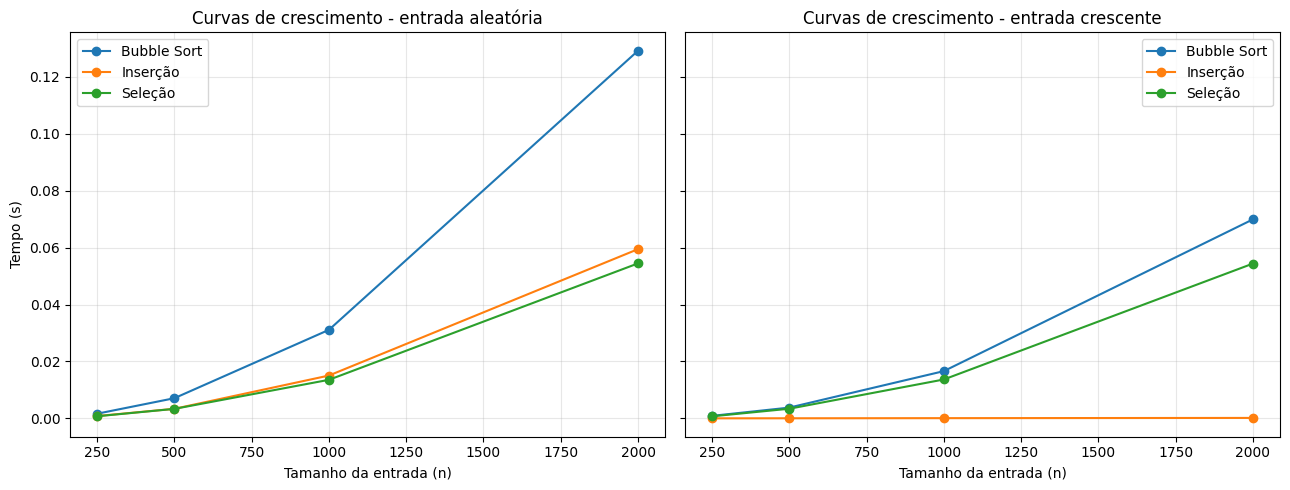

In [12]:
import random
import time
import pandas as pd
import matplotlib.pyplot as plt


def medir_curvas_crescimento(tamanhos):
    if (
        "bubble_sort" not in globals()
        or "insercao" not in globals()
        or "selecao" not in globals()
    ):
        raise RuntimeError("Execute antes as células que definem bubble_sort, insercao e selecao.")

    resultados = []

    for n in tamanhos:
        dados_aleatorios = [random.randint(0, 1_000_000) for _ in range(n)]
        dados_crescentes = list(range(n))

        cenarios = [
            ("Bubble Sort", bubble_sort),
            ("Inserção", insercao),
            ("Seleção", selecao),
        ]

        for algoritmo, func in cenarios:
            inicio = time.perf_counter()
            func(dados_aleatorios.copy())
            tempo_aleatorio = time.perf_counter() - inicio

            inicio = time.perf_counter()
            func(dados_crescentes.copy())
            tempo_crescente = time.perf_counter() - inicio

            resultados.append(
                {
                    "n": n,
                    "Algoritmo": algoritmo,
                    "Aleatório (s)": tempo_aleatorio,
                    "Crescente (s)": tempo_crescente,
                }
            )

    return pd.DataFrame(resultados)


# Ajuste se quiser curvas mais detalhadas; esses valores mantêm execução viável.
tamanhos = [250, 500, 1000, 2000]
curvas_df = medir_curvas_crescimento(tamanhos)

display(curvas_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for algoritmo in curvas_df["Algoritmo"].unique():
    dados_alg = curvas_df[curvas_df["Algoritmo"] == algoritmo]
    axes[0].plot(dados_alg["n"], dados_alg["Aleatório (s)"], marker="o", label=algoritmo)
    axes[1].plot(dados_alg["n"], dados_alg["Crescente (s)"], marker="o", label=algoritmo)

axes[0].set_title("Curvas de crescimento - entrada aleatória")
axes[0].set_xlabel("Tamanho da entrada (n)")
axes[0].set_ylabel("Tempo (s)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_title("Curvas de crescimento - entrada crescente")
axes[1].set_xlabel("Tamanho da entrada (n)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
if "curvas_df" not in globals() or curvas_df.empty:
    print("Execute primeiro a célula do gráfico para gerar o DataFrame curvas_df.")
else:
    import numpy as np

    primeira_linha = curvas_df["n"].min()
    ultima_linha = curvas_df["n"].max()

    def taxa_media_crescimento(coluna):
        fatores = []
        for algoritmo in curvas_df["Algoritmo"].unique():
            dados = curvas_df[curvas_df["Algoritmo"] == algoritmo].sort_values("n")
            t0 = dados[dados["n"] == primeira_linha][coluna].iloc[0]
            t1 = dados[dados["n"] == ultima_linha][coluna].iloc[0]
            fatores.append((algoritmo, (t1 / t0) if t0 > 0 else np.inf))
        return sorted(fatores, key=lambda x: x[1], reverse=True)

    crescimento_aleatorio = taxa_media_crescimento("Aleatório (s)")
    crescimento_crescente = taxa_media_crescimento("Crescente (s)")

    media_aleatorio = (
        curvas_df.groupby("Algoritmo")["Aleatório (s)"].mean().sort_values().index.tolist()
    )
    media_crescente = (
        curvas_df.groupby("Algoritmo")["Crescente (s)"].mean().sort_values().index.tolist()
    )

    texto_conclusao = f"""
Conclusão automática

Com base nas curvas medidas para n entre {primeira_linha} e {ultima_linha}, os três algoritmos apresentam crescimento compatível com custo quadrático em entrada aleatória, com piora mais acentuada no Bubble Sort.

No cenário aleatório, a ordem média de melhor para pior tempo foi: {', '.join(media_aleatorio)}.
No cenário já crescente, a ordem média foi: {', '.join(media_crescente)}.

O maior fator de crescimento no caso aleatório foi de {crescimento_aleatorio[0][0]} ({crescimento_aleatorio[0][1]:.2f}x entre o menor e o maior n).
No caso crescente, o maior fator de crescimento foi de {crescimento_crescente[0][0]} ({crescimento_crescente[0][1]:.2f}x).

Assim, para este experimento, Inserção tende a ser a alternativa mais eficiente em entradas já ordenadas, enquanto Bubble Sort e Seleção mantêm comportamento menos favorável conforme n aumenta.
""".strip()

    print(texto_conclusao)

Conclusão automática

Com base nas curvas medidas para n entre 250 e 2000, os três algoritmos apresentam crescimento compatível com custo quadrático em entrada aleatória, com piora mais acentuada no Bubble Sort.

No cenário aleatório, a ordem média de melhor para pior tempo foi: Seleção, Inserção, Bubble Sort.
No cenário já crescente, a ordem média foi: Inserção, Seleção, Bubble Sort.

O maior fator de crescimento no caso aleatório foi de Bubble Sort (78.74x entre o menor e o maior n).
No caso crescente, o maior fator de crescimento foi de Bubble Sort (78.96x).

Assim, para este experimento, Inserção tende a ser a alternativa mais eficiente em entradas já ordenadas, enquanto Bubble Sort e Seleção mantêm comportamento menos favorável conforme n aumenta.
